<a href="https://www.kaggle.com/code/gpreda/unemployment-benefits-for-25-49-ys-old-in-plymouth?scriptVersionId=259190190" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Analysis preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter

In [2]:
data_df = pd.read_csv("/kaggle/input/people-claiming-unemployment-benefits-in-plymouth/people-claiming-unemployment-benefits-between-25-49-plymouth.csv")

In [3]:
data_df.head(2)

,Month and Year,Claimants aged 25-49 in Plymouth,Claimants aged 25-49 Min all english county local authorities,Claimants aged 25-49 Avg all english county local authorities,Claimants aged 25-49 Max all english county local authorities
0,Jan-13,3275,2075,7074,15640
1,Feb-13,3340,2065,7197,15980


In [4]:
data_df.shape

(53, 5)

# Prepare the graph

In [5]:
# Convert Date in string to datetime
data_df["date"] = pd.to_datetime(data_df["Month and Year"].astype(str), format="%b-%y", errors="coerce")
data_df = data_df.sort_values("date")

In [6]:
data_df.head(5)

,Month and Year,Claimants aged 25-49 in Plymouth,Claimants aged 25-49 Min all english county local authorities,Claimants aged 25-49 Avg all english county local authorities,Claimants aged 25-49 Max all english county local authorities,date
0,Jan-13,3275,2075,7074,15640,2013-01-01
1,Feb-13,3340,2065,7197,15980,2013-02-01
2,Mar-13,3330,1940,7029,15585,2013-03-01
3,Apr-13,3200,1855,6803,15105,2013-04-01
4,May-13,3110,1795,6566,14620,2013-05-01


In [7]:
data_df.columns = ["Month-Year", "Plymouth", "Min", "Avg", "Max", "Date"]

In [8]:
# Ensure numeric and avoid non-positive values on log scale
for col in ["Plymouth", "Min", "Avg", "Max"]:
    data_df[col] = pd.to_numeric(data_df[col], errors="coerce")
    data_df[col] = data_df[col].where(data_df[col] > 0)  # drop zeros/negatives so log scale works

# Plot

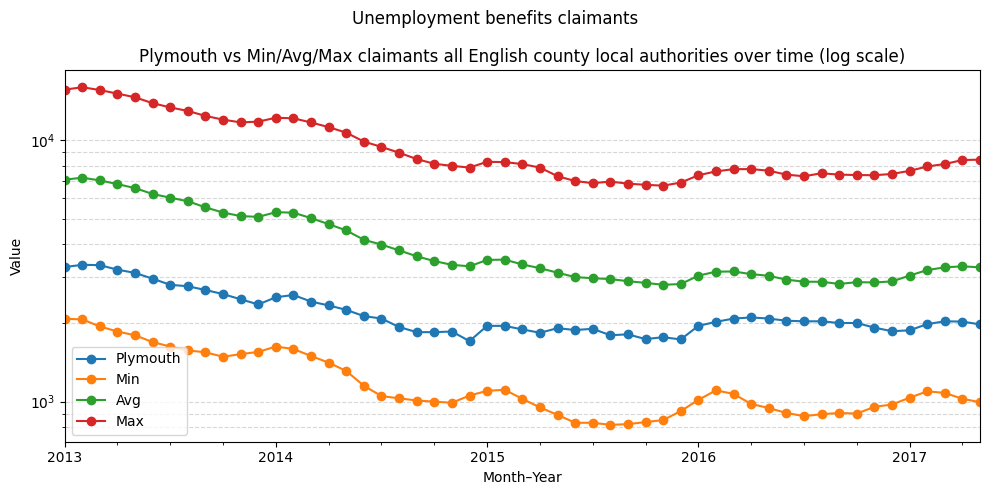

In [9]:
ax = data_df.plot(
    x="Date",
    y=["Plymouth", "Min", "Avg", "Max"],
    marker="o",
    figsize=(10, 5),
)

ax.set_yscale("log")
ax.set_xlabel("Month–Year")
ax.set_ylabel("Value")
plt.suptitle("Unemployment benefits claimants")
ax.set_title("Plymouth vs Min/Avg/Max claimants all English county local authorities over time (log scale)")
ax.legend(loc="best")
ax.grid(True, which="both", axis="y", linestyle="--", alpha=0.5)


plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()